In [1]:
import torch
import random
from tqdm import tqdm # 用于显示进度条，如果环境中没有可以去掉
import utilities  # 假设 utilities 模块已导入
import numpy as np
import matplotlib.pyplot as plt

import interconnect_calculator as inter_cal
import temperature_calculator as temp_cal
import chip_temp_pred_models as ctpm

import warnings
warnings.filterwarnings("ignore")

class Particle:
    """
    PSO 算法中的粒子类 (Particle Class)。
    每个粒子代表一个潜在的 Chiplet 布局解。
    """
    def __init__(self, chiplets, board_size, device='cuda', min_edge_distance: float = 0.2):
        """
        初始化粒子属性。

        Args:
            chiplets (dict): 芯片属性字典，用于生成初始布局。
            board_size (tuple): 画布尺寸 (grid_len, grid_wid)。
            device (str): 计算设备，默认为 'cuda'。
        """
        self.device = device
        self.chiplets = chiplets
        self.board_size = board_size
        
        # 解包画布尺寸
        grid_len, grid_wid = board_size

        # 1. 初始化位置 (Position/Layout)
        # 调用外部依赖函数生成初始的无重叠布局
        # Layout Tensor Shape: [N_chiplets, 5] -> [x, y, len, wid, index]
        # 确保数据在正确的 device 上
        self.layout = generate_a_layout_cuda(
            grid_len, grid_wid, chiplets, min_edge_distance=min_edge_distance
        ).to(self.device)

        # 2. 初始化速度 (Velocity)
        # 生成一个与 layout 形状相同的全零 Tensor
        # 虽然形状是 [N, 5]，但在 PSO 更新逻辑中，我们通常只更新前两列 (x, y) 的速度
        self.velocity = torch.zeros_like(self.layout, device=self.device)

        # 3. 初始化个体历史最优 (Personal Best - pBest)
        # 初始时刻，粒子最好的位置就是它当前的位置
        # 关键：使用 .clone() 进行深拷贝，避免引用被后续的移动操作修改
        self.pbest_layout = self.layout.clone()

        # 4. 初始化能量/适应度 (Energy/Cost)
        # 初始化为正无穷大，表示尚未进行评估
        self.current_energy = float('inf')
        self.pbest_energy = float('inf')

    def update_personal_best(self, new_energy):
        """
        根据新的能量值更新粒子的个体历史最优 (pBest)。

        Args:
            new_energy (float): 当前布局对应的能量值 (Energy/Cost)。
        """
        # 更新当前能量状态
        self.current_energy = new_energy

        # 检查当前能量是否优于历史最优能量 (越小越好)
        if new_energy < self.pbest_energy:
            self.pbest_energy = new_energy
            # 发现更好的位置，更新 pbest_layout
            # 再次强调：必须使用 .clone()，否则 pbest 会随着 layout 的后续更新而变化
            self.pbest_layout = self.layout.clone()

g:\VScode\CTAD2\CTAD2_PSO_test\stage2_1\chip_temp_pred_models.py:122: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  inchip_pred_model.load_state_dict(torch.load(inchip_model

In [2]:

# 自动检测设备
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ==========================================
# 辅助函数：重叠检测 (依赖项)
# ==========================================
def is_2_chip_overlapping_cuda(chip1, chip2, min_edge_dist: float = 0.2):
    """
    检测两个芯粒是否重叠
    """
    x1, y1, w1, h1 = chip1[0], chip1[1], chip1[2], chip1[3]
    x2, y2, w2, h2 = chip2[0], chip2[1], chip2[2], chip2[3]

    # 判断不重叠的条件 (逆向思维)
    no_overlap = (
        (x1 + w1 + min_edge_dist <= x2) or
        (x2 + w2 + min_edge_dist <= x1) or
        (y1 + h1 + min_edge_dist <= y2) or
        (y2 + h2 + min_edge_dist <= y1)
    )
    return not no_overlap

def check_overlap_within_layout_cuda(layout, min_edge_dist: float = 0.2):
    """
    检测整个布局中是否存在任何重叠
    """
    if not torch.is_tensor(layout):
        layout = torch.tensor(layout, device=DEVICE)
    
    n = len(layout)
    if n <= 1: return False
    
    # 获取上三角索引 (排除自身对比和重复对比)
    i_indices, j_indices = torch.triu_indices(n, n, offset=1)
    
    overlaps = [
        bool(is_2_chip_overlapping_cuda(layout[i], layout[j], min_edge_dist=min_edge_dist))
        for i, j in zip(i_indices, j_indices)
    ]

    return any(overlaps)

def is_overlapping_in_init_grid_cuda(x_c, y_c, len_c, wid_c, index_c, layout, min_edge_dist=0.2): 
    """
    检查新生成的芯片是否与布局中已有的芯片重叠 (用于初始化)
    """
    if len(layout) == 0:
        return False
        
    curr_chip = torch.tensor([x_c, y_c, len_c, wid_c, index_c], device=DEVICE)
    
    for i in range(len(layout)):
        if is_2_chip_overlapping_cuda(curr_chip, layout[i], min_edge_dist):
            return True
            
    return False

# ==========================================
# 核心函数 1：生成初始布局 (修复 NameError)
# ==========================================
def get_chiplet_dict_cuda(chip_length, chip_width, Convection_Film_Coefficient, Internal_Heat_Generation_Magnitude):
    """
    生成单个芯粒参数字典。
    这里调用与 stage2_1_cuda03 相同的热模型系数拟合函数，确保 A/k 口径一致。
    """
    chip = dict()
    chip['len'] = chip_length
    chip['wid'] = chip_width
    chip['CFC'] = Convection_Film_Coefficient
    chip['IHGM'] = Internal_Heat_Generation_Magnitude

    chip['A'], chip['k'] = ctpm.get_out_chip_decay_curve_coef(
        chip_len=chip['len'],
        chip_wid=chip['wid'],
        Convection_Film_Coefficient=chip['CFC'],
        Internal_Heat_Generation_Magnitude=chip['IHGM']
    )
    return chip


def generate_a_layout_cuda(grid_length, grid_width, chiplets: dict, min_edge_distance: float=2.0, margin_width: float=1.0):
    """
    随机生成一个无重叠的初始布局。
    为了与 stage2_1_cuda03 对齐，这里严格要求芯片之间不重叠。
    """
    layout = torch.tensor([], device=DEVICE)

    for index, chip in chiplets.items():
        placed = False

        while not placed:
            x = random.randint(0, int(grid_length - chip['len']))
            y = random.randint(0, int(grid_width - chip['wid']))

            if len(layout) >= 1:
                if not is_overlapping_in_init_grid_cuda(
                    x, y, chip['len'], chip['wid'], index, layout, min_edge_dist=min_edge_distance
                ):
                    chip_tensor = torch.tensor([x, y, chip['len'], chip['wid'], index], device=DEVICE)
                    layout = torch.cat((layout, chip_tensor.unsqueeze(0)), dim=0)
                    placed = True
            else:
                chip_tensor = torch.tensor([x, y, chip['len'], chip['wid'], index], device=DEVICE)
                layout = torch.cat((layout, chip_tensor.unsqueeze(0)), dim=0)
                placed = True

    if len(layout) > 0:
        x_min = torch.min(layout[:, 0]).item()
        y_min = torch.min(layout[:, 1]).item()
        layout[:, 0] -= (x_min - margin_width)
        layout[:, 1] -= (y_min - margin_width)

    return layout

def calculate_energy(layout, connectivity, chiplets, weights=None, min_edge_distance: float = 0.2):
    """
    计算 Chiplet 布局的能量值 (Cost/Fitness)
    """
    if weights is None:
        weights = {
            'interconnect': 1.0,      # 连线长度权重
            'temp_uniformity': 1.0,   # 温度均匀度权重
            'max_temp': 0.1,          # 最大温度权重
            'overlap': 10000.0,       # 重叠惩罚权重 (硬约束)
            'spread': 0.2             # 分散惩罚权重
        }
    
    if not torch.is_tensor(layout):
        layout = torch.tensor(layout, device=DEVICE, dtype=torch.float32)
    else:
        layout = layout.to(DEVICE)

    # 1. 计算连线长度
    inter_connect_length = inter_cal.get_total_interconnect_length_cuda(
        layout=layout,
        connectivity_pairs=connectivity
    )

    # 2. 计算热分布
    max_temp, temp_uniformity = temp_cal.get_max_temp_and_temp_uniformity_cuda(
        layout, chiplets
    )

    # 3. 计算重叠惩罚
    is_overlapping = check_overlap_within_layout_cuda(layout, min_edge_dist=min_edge_distance)
    overlap_penalty = weights['overlap'] if is_overlapping else 0.0

    # 4. 计算分散惩罚
    center_coords = torch.stack([
        layout[:, 0] + layout[:, 2] * 0.5,
        layout[:, 1] + layout[:, 3] * 0.5
    ], dim=1)
    
    centroid = center_coords.mean(dim=0)
    diff = center_coords - centroid
    dist_sq = diff[:, 0]**2 + diff[:, 1]**2
    spread_penalty = dist_sq.sum()

    # 5. 汇总能量值
    total_energy = (
        weights['interconnect'] * inter_connect_length +
        weights['temp_uniformity'] * temp_uniformity +
        weights['max_temp'] * max_temp +
        overlap_penalty + 
        weights['spread'] * spread_penalty
    )

    if torch.is_tensor(total_energy):
        return total_energy.item()
    return total_energy

def validate_connectivity_pairs(connectivity, chiplets):
    """
    校验连线定义是否合法。
    目的：在优化开始前就发现错误输入，避免后续出现难定位的下标异常。
    """
    valid_ids = set(chiplets.keys())
    invalid_pairs = []

    for pair, _weight in connectivity:
        i, j = pair
        if (i not in valid_ids) or (j not in valid_ids):
            invalid_pairs.append((i, j))

    if invalid_pairs:
        raise ValueError(
            f"非法连线端点: {invalid_pairs}；当前合法芯片索引: {sorted(valid_ids)}"
        )

def get_fitness_breakdown_cuda(layout, connectivity, chiplets, weights=None, min_edge_distance: float = 0.2):
    """
    ??????? fitness ????????????????????????
    """
    if weights is None:
        weights = {
            'interconnect': 1.0,
            'temp_uniformity': 1.0,
            'max_temp': 0.1,
            'overlap': 10000.0,
            'spread': 0.2,
        }

    if not torch.is_tensor(layout):
        layout = torch.tensor(layout, device=DEVICE, dtype=torch.float32)
    else:
        layout = layout.to(DEVICE).float()

    inter_connect_length = inter_cal.get_total_interconnect_length_cuda(
        layout=layout,
        connectivity_pairs=connectivity,
    )
    max_temp, temp_uniformity = temp_cal.get_max_temp_and_temp_uniformity_cuda(layout, chiplets)

    overlap_raw = 1.0 if check_overlap_within_layout_cuda(layout, min_edge_dist=min_edge_distance) else 0.0
    overlap_penalty = weights['overlap'] if overlap_raw > 0 else 0.0

    center_coords = torch.stack([
        layout[:, 0] + layout[:, 2] * 0.5,
        layout[:, 1] + layout[:, 3] * 0.5,
    ], dim=1)
    centroid = center_coords.mean(dim=0)
    diff = center_coords - centroid
    dist_sq = diff[:, 0]**2 + diff[:, 1]**2
    spread_raw = dist_sq.sum()

    def _to_float(x):
        return x.item() if torch.is_tensor(x) else float(x)

    breakdown = {
        'interconnect': {
            'raw': _to_float(inter_connect_length),
            'weight': float(weights['interconnect']),
            'weighted': float(weights['interconnect']) * _to_float(inter_connect_length),
        },
        'temp_uniformity': {
            'raw': _to_float(temp_uniformity),
            'weight': float(weights['temp_uniformity']),
            'weighted': float(weights['temp_uniformity']) * _to_float(temp_uniformity),
        },
        'max_temp': {
            'raw': _to_float(max_temp),
            'weight': float(weights['max_temp']),
            'weighted': float(weights['max_temp']) * _to_float(max_temp),
        },
        'spread': {
            'raw': _to_float(spread_raw),
            'weight': float(weights['spread']),
            'weighted': float(weights['spread']) * _to_float(spread_raw),
        },
        'overlap': {
            'raw': overlap_raw,
            'weight': float(weights['overlap']),
            'weighted': float(overlap_penalty),
        },
    }
    breakdown['total'] = sum(item['weighted'] for item in breakdown.values())
    return breakdown
def print_pso_final_scores(layout, connectivity, chiplets, weights=None, method_name="PSO Optimization", min_edge_distance: float = 0.2):
    """
    ?? PSO ??????????????????????????????
    """
    if not torch.is_tensor(layout):
        layout = torch.tensor(layout, device=DEVICE)
    else:
        layout = layout.to(DEVICE)

    breakdown = get_fitness_breakdown_cuda(layout, connectivity, chiplets, weights=weights, min_edge_distance=min_edge_distance)

    print(f"\n{'='*20} {method_name} Final Results {'='*20}")
    print(f"?????? (Final Layout Tensor):\n{layout.detach().cpu().numpy()}")
    print("-" * 78)

    metric_items = [
        ('interconnect', 'Interconnect'),
        ('temp_uniformity', 'TempUniformity'),
        ('max_temp', 'MaxTemp'),
        ('spread', 'Spread'),
        ('overlap', 'Overlap'),
    ]
    total_score = breakdown['total']
    print(f"{'Metric':<15} {'Raw':>12} {'Weight':>12} {'Weighted':>14} {'Ratio(%)':>12}")
    for metric_key, metric_name in metric_items:
        item = breakdown[metric_key]
        ratio = (item['weighted'] / total_score * 100.0) if abs(total_score) > 1e-12 else 0.0
        print(
            f"{metric_name:<15} {item['raw']:>12.4f} {item['weight']:>12.4f} {item['weighted']:>14.4f} {ratio:>11.2f}%"
        )

    print("-" * 78)
    total_ratio = 100.0 if abs(total_score) > 1e-12 else 0.0
    print(f"{'Total Fitness':<15} {'':>12} {'':>12} {total_score:>14.4f} {total_ratio:>11.2f}%")
    print("=" * 78 + "\n")

    return breakdown['interconnect']['raw'], breakdown['temp_uniformity']['raw']


In [3]:

class PSOOptimizer:
    """
    PSO 核心优化引擎 (PSO Optimizer Class)。
    负责管理粒子群，执行速度/位置更新，并维护全局最优状态。
    """
    def __init__(self, num_particles, chiplets, connectivity, board_size, device='cuda', min_edge_distance: float = 0.2):
        """
        初始化 PSO 优化器。

        Args:
            num_particles (int): 粒子数量 (种群大小)。
            chiplets (dict): 芯片属性字典。
            connectivity (list): 连通性列表。
            board_size (tuple): 画布尺寸 (grid_len, grid_wid)。
            device (str): 计算设备。
        """
        self.num_particles = num_particles
        self.chiplets = chiplets
        # 先做输入合法性校验，避免后续在底层计算函数中报难定位的索引错误
        validate_connectivity_pairs(connectivity, chiplets)
        self.connectivity = connectivity
        self.board_size = board_size
        self.device = device
        self.min_edge_distance = float(min_edge_distance)
        
        # 1. 初始化超参数
        self.w = 0.7   # 惯性权重 (Inertia Weight): 保持运动惯性
        self.c1 = 1.4  # 个体学习因子 (Cognitive Component): 向个体最优学习
        self.c2 = 1.4  # 社会学习因子 (Social Component): 向全局最优学习

        # 2. 初始化粒子群
        # 创建包含 num_particles 个 Particle 对象的列表
        # 注意：这里假设 Particle 类已经在外部定义并导入
        self.particles = [
            Particle(chiplets, board_size, device, min_edge_distance=self.min_edge_distance) 
            for _ in range(num_particles)
        ]

        # 3. 初始化全局最优 (Global Best - gBest)
        self.gbest_layout = None
        self.gbest_energy = float('inf')

    def optimize(self, iterations=100, weights=None):
        """
        执行 PSO 主优化循环。

        Args:
            iterations (int): 迭代次数。
            weights (dict): 能量函数的权重配置。

        Returns:
            tuple: (best_layout, energy_history)
        """
        energy_history = []
        
        print(f"Starting PSO Optimization on {self.device}...")
        
        # 使用 tqdm 显示进度条 (可选)
        iterator = tqdm(range(iterations), desc="PSO Iterations")
        
        for i in iterator:
            # === 步骤 1: 计算能量 & 更新最优解 ===
            for p in self.particles:
                # 1.1 计算当前粒子的能量
                # 注意：这里调用外部依赖函数 calculate_energy
                energy = calculate_energy(
                    p.layout,
                    self.connectivity,
                    self.chiplets,
                    weights,
                    min_edge_distance=self.min_edge_distance,
                )
                
                # 1.2 更新粒子的个体最优 (pBest)
                p.update_personal_best(energy)
                
                # 1.3 更新全局最优 (gBest)
                if energy < self.gbest_energy:
                    self.gbest_energy = energy
                    # 关键：必须深拷贝，否则会被后续更新覆盖
                    self.gbest_layout = p.layout.clone()
            
            # 记录历史数据
            energy_history.append(self.gbest_energy)
            
            # 如果还没找到有效解(极少数情况)，跳过更新直接继续
            if self.gbest_layout is None:
                continue

            # === 步骤 2: 更新粒子的速度和位置 ===
            for p in self.particles:
                # 随机向量 r1, r2 (形状与 x, y 坐标一致)
                # p.layout 形状为 [N, 5]，我们只需要 [N, 2] 的随机数
                r1 = torch.rand(p.layout.size(0), 2, device=self.device)
                r2 = torch.rand(p.layout.size(0), 2, device=self.device)

                # --- 核心公式：更新速度 ---
                # v = w*v + c1*r1*(pbest - current) + c2*r2*(gbest - current)
                # 关键约束：只更新前两列 (velocity[:, :2])
                
                # 计算认知部分 (个体经验)
                cognitive = self.c1 * r1 * (p.pbest_layout[:, :2] - p.layout[:, :2])
                
                # 计算社会部分 (群体经验)
                social = self.c2 * r2 * (self.gbest_layout[:, :2] - p.layout[:, :2])
                
                # 更新速度张量的前两列
                p.velocity[:, :2] = (self.w * p.velocity[:, :2]) + cognitive + social

                # --- 更新位置 ---
                # pos = pos + v
                # 关键约束：只更新前两列 (layout[:, :2])
                p.layout[:, :2] = p.layout[:, :2] + p.velocity[:, :2]

                # === 步骤 3: 边界限制 (Clamping) ===
                # 确保芯片不飞出画板
                # 约束：0 <= x <= board_len - chip_len
                #      0 <= y <= board_wid - chip_wid
                
                board_len, board_wid = self.board_size
                
                # 获取每个芯片的长度 (第3列, index 2) 和 宽度 (第4列, index 3)
                chip_lens = p.layout[:, 2]
                chip_wids = p.layout[:, 3]
                
                # 计算 x 和 y 的允许最大值
                max_x = board_len - chip_lens
                max_y = board_wid - chip_wids
                
                # 使用 torch.clamp 进行截断
                # 注意：min=0 是标量，max 必须是对应的张量
                p.layout[:, 0] = torch.min(torch.max(p.layout[:, 0], torch.tensor(0.0, device=self.device)), max_x)
                p.layout[:, 1] = torch.min(torch.max(p.layout[:, 1], torch.tensor(0.0, device=self.device)), max_y)

            # 更新进度条显示的当前最优值
            iterator.set_postfix({"Best Energy": f"{self.gbest_energy:.4f}"})

        print("Optimization Finished.")
        return self.gbest_layout, energy_history

In [4]:


def calculate_swarm_energy(particles, connectivity, chiplets, weights=None, min_edge_distance: float = 0.2):
    """
    计算整个粒子群的能量/适应度 (Fitness Function Wrapper)。
    作为 PSO 优化器与底层能量计算函数之间的桥梁，批量更新粒子的能量状态。

    Args:
        particles (list): 包含多个 Particle 对象的列表 (来自模块一)。
        connectivity (list): 连通性列表，传递给底层 calculate_energy 函数。
        chiplets (dict): 芯片属性字典，传递给底层 calculate_energy 函数。
        weights (dict, optional): 能量函数的权重配置字典。

    Returns:
        list: 包含所有粒子当前能量值的列表，便于后续统计分析。
    """
    energies = []

    # 遍历粒子群中的每一个粒子
    for particle in particles:
        # 1. 提取粒子的当前布局 (layout)
        # particle.layout 是一个 Shape 为 [N, 5] 的 Tensor
        current_layout = particle.layout

        # 2. 调用现有的能量计算函数
        # 注意：这里假设 calculate_energy 已经在外部定义并导入
        # 它负责处理具体的连线长度、热分布和重叠惩罚计算
        energy = calculate_energy(
            layout=current_layout,
            connectivity=connectivity,
            chiplets=chiplets,
            weights=weights,
            min_edge_distance=min_edge_distance
        )

        # 3. 关键步骤：直接更新粒子的当前能量属性
        # 这一步将计算结果绑定回粒子对象，供 PSO 更新公式使用 (用于对比 pBest)
        particle.current_energy = energy

        # 4. 收集能量值
        energies.append(energy)

    return energies

In [6]:

# ==========================================
# 1. 数据准备 (Data Setup)
# ==========================================
print("Setting up data for PSO...")

# 标准测试数据 (与 SA 算法对比)
# 格式: [Length, Width, CFC, IHGM]
raw_input = [
    [9, 9, 15, 140000000], 
    [6, 6, 15, 300000000],
    [5, 5, 15, 80000000] 
    #[4, 4, 15, 120000000]
    
]

# ???????????????????????????
min_chip_spacing = 1.0

# 构建 chiplets 字典
chiplets = {}
for i, d in enumerate(raw_input):
    # 使用与 stage2_1_cuda03 相同的参数生成函数，保证 A/k 计算口径一致。
    chiplets[i] = get_chiplet_dict_cuda(
        chip_length=d[0],
        chip_width=d[1],
        Convection_Film_Coefficient=d[2],
        Internal_Heat_Generation_Magnitude=d[3]
    )

connectivity = [[(0, 1), 1], [(1, 2), 2], [(0, 2), 1]]

# 估算画布大小 (用于边界限制)
# 逻辑：平均尺寸 * (N + 10) + 10
avg_len = sum([c['len'] for c in chiplets.values()]) / len(chiplets)
avg_wid = sum([c['wid'] for c in chiplets.values()]) / len(chiplets)
num_chips = len(chiplets)
grid_len = (avg_len + 10) * num_chips + 10
grid_wid = (avg_wid + 10) * num_chips + 10
board_size = (grid_len, grid_wid)

print(f"Board Size set to: {board_size}")

# 自动检测设备
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ==========================================
# 2. 执行优化 (Execution)
# ==========================================
print(f"\nInitializing PSO Optimizer on {device}...")

# 初始化优化器
# 注意：PSOOptimizer 类需在之前的单元格中定义
# 在迭代运行前统一控制芯片间最小间距（后续只需修改这一处）
pso_optimizer = PSOOptimizer(
    num_particles=50,       # 粒子数量
    chiplets=chiplets,
    connectivity=connectivity,
    board_size=board_size,
    device=device,
    min_edge_distance=min_chip_spacing
)

# 运行优化前统一设置 fitness 权重（后续调参只改这里）
fitness_weights = {
    'interconnect': 1.0,    # 连线长度权重：越短越好
    'temp_uniformity': 1.0, # 温度均匀性权重：方差越小越好
    'max_temp': 0.1,        # 最大温度权重：最高温越低越好
    'spread': 0.2,          # 分散度权重：鼓励布局更均匀展开
    'overlap': 10000.0      # 重叠惩罚权重：一旦重叠就强力惩罚
}

# 运行优化
print("Starting optimization loop...")
best_layout, history = pso_optimizer.optimize(
    iterations=200,
    weights=fitness_weights
)

print("Optimization Finished!")

def build_layout(best_positions, input_data):
    if torch.is_tensor(best_positions):
        rows = best_positions.detach().cpu().tolist()
    else:
        rows = best_positions

    layout = []
    for row_i, row in enumerate(rows):
        x = round(float(row[0]), 4)
        y = round(float(row[1]), 4)

        chip_idx = int(row_i)
        if len(row) >= 5:
            idx_raw = float(row[4])
            idx_int = int(idx_raw)
            if abs(idx_raw - idx_int) <= 1e-6 and 0 <= idx_int < len(input_data):
                chip_idx = idx_int

        if chip_idx < 0 or chip_idx >= len(input_data):
            raise ValueError(f"chip_idx out of range: {chip_idx}, valid [0, {len(input_data)-1}]")

        if len(row) >= 4:
            width = float(row[2])
            height = float(row[3])
        else:
            width = float(input_data[chip_idx][0])
            height = float(input_data[chip_idx][1])

        h = float(input_data[chip_idx][2])
        power_density = float(input_data[chip_idx][3])

        layout.append([
            x,
            y,
            width,
            height,
            h,
            power_density,
            int(chip_idx),
        ])

    for out_row in layout:
        idx = int(out_row[6])
        in_w = float(input_data[idx][0])
        in_h = float(input_data[idx][1])
        out_w = float(out_row[2])
        out_h = float(out_row[3])

        same_order = abs(out_w - in_w) <= 1e-6 and abs(out_h - in_h) <= 1e-6
        swapped_order = abs(out_w - in_h) <= 1e-6 and abs(out_h - in_w) <= 1e-6
        if not (same_order or swapped_order):
            raise ValueError(f"width/height mismatch at chip_idx={idx}: output=({out_w}, {out_h}), input=({in_w}, {in_h})")

    return layout


layout = build_layout(best_layout, raw_input)
print("\nPSO best fitness layout (unified format):")
print("layout = [")
for row in layout:
    print(f"    {row},")
print("]")

# ==========================================
# 3. 结果可视化 (Visualization)
# ==========================================

# --- 图表 1：收敛曲线 ---
plt.figure(figsize=(10, 6))

# 确保 history 数据在 CPU 上 (如果是 Tensor 列表)
history_cpu = [h.item() if torch.is_tensor(h) else h for h in history]

import csv
pso_csv_path = "pso_fitness_history.csv"
with open(pso_csv_path, mode="w", newline="", encoding="utf-8-sig") as f:
    writer = csv.writer(f)
    writer.writerow(["iteration", "fitness"])
    for iter_idx, score in enumerate(history_cpu):
        writer.writerow([iter_idx, float(score)])
print(f"PSO CSV exported: {pso_csv_path}")

plt.plot(range(len(history_cpu)), history_cpu, label='Global Best Energy', color='green', linewidth=2)
plt.title('PSO Optimization Convergence Curve', fontsize=15)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Fitness / Cost', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 标记最终值
final_score = history_cpu[-1]
plt.scatter(len(history_cpu)-1, final_score, color='red', s=50, zorder=5)
plt.text(len(history_cpu)-1, final_score, f' Final: {final_score:.4f}', 
         fontsize=12, color='red', verticalalignment='bottom')

plt.legend()
plt.show()

# --- 图表 2：最终布局可视化 ---
print("\nVisualizing Best Layout:")
try:
    # 调用 utilities 中的绘图函数
    # 先把 CUDA Tensor 移到 CPU，避免 numpy 转换时报错
    plot_layout = best_layout.detach().cpu() if torch.is_tensor(best_layout) else best_layout
    utilities.show_chip_design_cuda(plot_layout)
except Exception as e:
    print(f"Visualization Error: {e}")

# ==========================================
# 4. 指标报告 (Reporting)
# ==========================================
print("\nGenerating Final Report...")

# 调用 PSO 版本的指标函数，输出连线和温度评分


Setting up data for PSO...
Board Size set to: (60.0, 60.0)

Initializing PSO Optimizer on cpu...
Starting optimization loop...
Starting PSO Optimization on cpu...


PSO Iterations:   0%|          | 0/200 [00:00<?, ?it/s]


RuntimeError: a Tensor with 0 elements cannot be converted to Scalar

In [6]:
import torch
import interconnect_calculator as inter_cal
import temperature_calculator as temp_cal

# 确保定义了设备，防止报错
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def print_pso_final_scores(layout, connectivity, chiplets, weights=None, method_name="PSO Optimization", min_edge_distance: float = 0.2):
    """
    ?? PSO ??????????????????????????????
    """
    if not torch.is_tensor(layout):
        layout = torch.tensor(layout, device=DEVICE)
    else:
        layout = layout.to(DEVICE)

    breakdown = get_fitness_breakdown_cuda(layout, connectivity, chiplets, weights=weights, min_edge_distance=min_edge_distance)

    print(f"\n{'='*20} {method_name} Final Results {'='*20}")
    print(f"?????? (Final Layout Tensor):\n{layout.detach().cpu().numpy()}")
    print("-" * 78)

    metric_items = [
        ('interconnect', 'Interconnect'),
        ('temp_uniformity', 'TempUniformity'),
        ('max_temp', 'MaxTemp'),
        ('spread', 'Spread'),
        ('overlap', 'Overlap'),
    ]
    total_score = breakdown['total']
    print(f"{'Metric':<15} {'Raw':>12} {'Weight':>12} {'Weighted':>14} {'Ratio(%)':>12}")
    for metric_key, metric_name in metric_items:
        item = breakdown[metric_key]
        ratio = (item['weighted'] / total_score * 100.0) if abs(total_score) > 1e-12 else 0.0
        print(
            f"{metric_name:<15} {item['raw']:>12.4f} {item['weight']:>12.4f} {item['weighted']:>14.4f} {ratio:>11.2f}%"
        )

    print("-" * 78)
    total_ratio = 100.0 if abs(total_score) > 1e-12 else 0.0
    print(f"{'Total Fitness':<15} {'':>12} {'':>12} {total_score:>14.4f} {total_ratio:>11.2f}%")
    print("=" * 78 + "\n")

    return breakdown['interconnect']['raw'], breakdown['temp_uniformity']['raw']


In [7]:
# 假设你已经运行了 PSO 优化
# best_layout, history = pso_optimizer.optimize(iterations=200)

# 直接调用展示函数
wl_score, temp_score = print_pso_final_scores(
    layout=best_layout, 
    connectivity=connectivity, 
    chiplets=chiplets, 
    weights=fitness_weights,
    method_name="Particle Swarm Optimization",
    min_edge_distance=min_chip_spacing
)



==================== Particle Swarm Optimization Final Results ====================
最终布局方案 (Final Layout Tensor):
[[11.8057 26.5654  9.      9.      0.    ]
 [ 5.6057 25.4347  6.      6.      1.    ]
 [ 6.1825 31.6347  5.      5.      2.    ]
 [21.0058 29.0663  4.      4.      3.    ]]
------------------------------------------------------------
1. 连线长度得分 (Interconnect Length Score): 62.8452
   (数值越小，代表芯片间通信距离越短，性能越好)
------------------------------------------------------------
2. 温度均匀性得分 (Temp Uniformity Score)  : 36.2056
   (数值越小，代表热分布越均匀，散热风险越低)



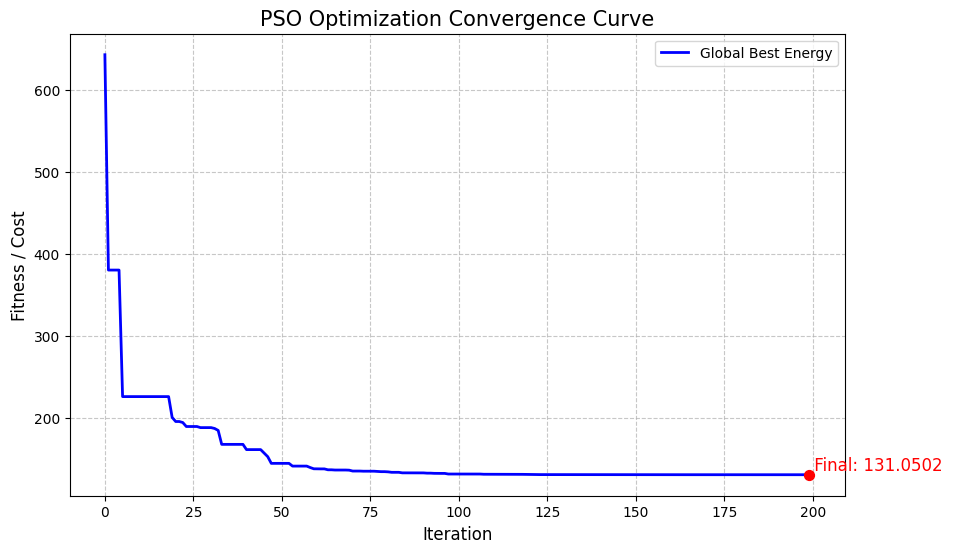


Visualizing Best Layout:


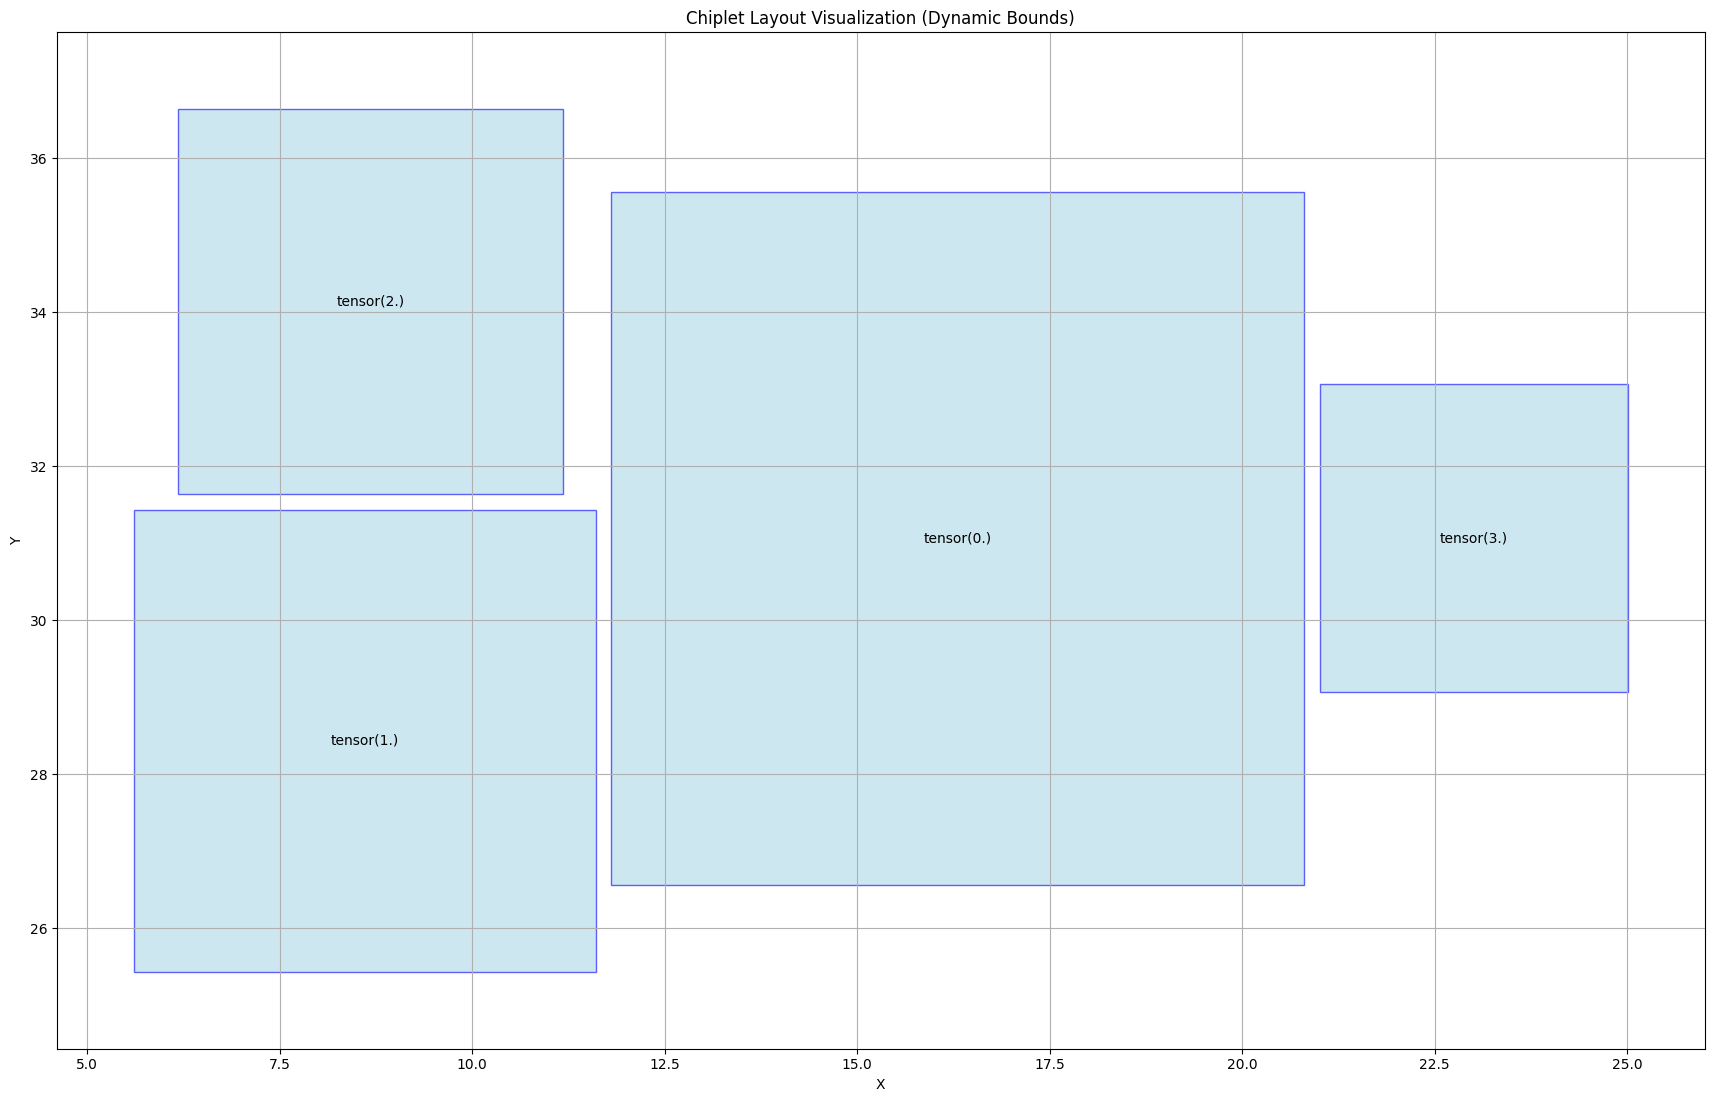


Generating Final Report...
Final Energy: 131.0502


In [8]:
# ==========================================
# 3. 结果可视化 (Visualization)
# ==========================================

# --- 图表 1：收敛曲线 ---
plt.figure(figsize=(10, 6))

# 确保 history 数据在 CPU 上 (如果是 Tensor 列表)
history_cpu = [h.item() if torch.is_tensor(h) else h for h in history]

import csv
pso_csv_path = "pso_fitness_history.csv"
with open(pso_csv_path, mode="w", newline="", encoding="utf-8-sig") as f:
    writer = csv.writer(f)
    writer.writerow(["iteration", "fitness"])
    for iter_idx, score in enumerate(history_cpu):
        writer.writerow([iter_idx, float(score)])
print(f"PSO CSV exported: {pso_csv_path}")

plt.plot(range(len(history_cpu)), history_cpu, label='Global Best Energy', color='blue', linewidth=2)
plt.title('PSO Optimization Convergence Curve', fontsize=15)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Fitness / Cost', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 标记最终值
final_score = history_cpu[-1]
plt.scatter(len(history_cpu)-1, final_score, color='red', s=50, zorder=5)
plt.text(len(history_cpu)-1, final_score, f' Final: {final_score:.4f}', 
         fontsize=12, color='red', verticalalignment='bottom')

plt.legend()
plt.show()

# --- 图表 2：最终布局可视化 ---
print("\nVisualizing Best Layout:")
try:
    # 调用 utilities 中的绘图函数
    # 先把 CUDA Tensor 移到 CPU，避免 numpy 转换时报错
    plot_layout = best_layout.detach().cpu() if torch.is_tensor(best_layout) else best_layout
    utilities.show_chip_design_cuda(plot_layout)
except Exception as e:
    print(f"Visualization Error: {e}")

# ==========================================
# 4. 指标报告 (Reporting)
# ==========================================
print("\nGenerating Final Report...")

# 调用 PSO 版本的指标函数，输出连线和温度评分
